# Всероссийская студенческая Актионада – Кейс-чемпионат «РЕСТАРТ» 2025 по направлению «IT» 2 этап

## Задание 3. Классификация бухгалтерских проводок — на основе USA Banking Transactions Dataset

**Описание задачи:** У компании есть выгрузка транзакций (аналог бухгалтерских проводок): дата, сумма, тип операции (дебет/кредит или Debit/Credit), контрагент (merchant), категория расходов (например, еда, транспорт, подписки и т.п.), возможно описание операции и способ оплаты.

Каждая транзакция должна быть отнесена к одной из категорий транзакций — например: Food, Transport, Entertainment, Grocery, Electronics и т.д.

**Данные:**

A. Сведения о транзакции:
- `Transaction_ID`: уникальный идентификатор каждой транзакции
- `Transaction_Date`: дата и время транзакции
- `Transaction_Amount`: денежная сумма транзакции
- `Transaction_Type`: тип транзакции (Debit или Credit)

B. Информация о клиенте:
- `Customer_Age`: возраст клиента (18–70)
- `Customer_Gender`: пол клиента (Male, Female, Others)
- `Customer_Income`: годовой доход клиента
- `Account_Balance`: остаток на счете после транзакции

C. Классификация:
- `Category`: классификация транзакций по соответствующим категориям, таким как Food, Transport, Entertainment, Grocery, Electronics и т.д.

D. Информация о продавце и способе оплаты:
- `Merchant_Name`: название продавца или поставщика
- `Payment_Method`: способ оплаты (Credit Card, Debit Card, Cash, Online Transfer и т.д.)

E. Дополнительные сведения:
- `City`: место проведения транзакции (крупные города США)
- `Fraud_Flag`: указывает, была ли транзакция помечена как мошенническая
- `Transaction_Status`: статус транзакции (Success, Failed, Pending)
- `Loyalty_Points_Earned`: бонусные баллы, начисленные за транзакцию
- `Discount_Applied`: логическое значение, указывающее, была ли применена скидка

**Метрика оценки качества:**

Macro F1-score (среднее макро по всем категориям).

**Задания:**

1. Визуализируйте распределение транзакций по всем классам. Определите 5% наименее представленных классов.
2. Разработайте и реализуйте код пайплайна, который выполняет:
    - Векторизацию текстового поля Note с помощью метода CountVectorizer с параметрами по умолчанию.
    - Объединение всех признаков (числовых, категориальных, временных, текстовых) в единую матрицу для обучения.
3. Сравните методы по итоговому macro F1-score.

### Загрузка и обзор данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
from lightgbm import LGBMClassifier

In [2]:
try:
    df = pd.read_csv('Banking_Transactions_USA_2023_2024.csv')
except:
    df = pd.read_csv(r'C:\ds_projects\actionada\Task_3\Banking_Transactions_USA_2023_2024.csv')
df.head()

,Transaction_ID,Account_Number,Transaction_Date,Transaction_Amount,Merchant_Name,Transaction_Type,Category,City,Country,Payment_Method,Customer_Age,Customer_Gender,Customer_Occupation,Customer_Income,Account_Balance,Transaction_Status,Fraud_Flag,Discount_Applied,Loyalty_Points_Earned,Transaction_Description
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,IUPM04409079772781,2023-11-05 15:54:38,3198.94,Houston Group,Debit,Transport,Phoenix,USA,Online Transfer,55,Others,Quality manager,80466.03,350.28,Failed,No,True,304,Recently company detail form range a.
1,23b8c1e9-3924-46de-beb1-3b9046685257,BLAT22216107051843,2024-04-21 22:21:55,129.93,Anderson-Phillips,Credit,Grocery,Philadelphia,USA,Debit Card,26,Others,Civil Service fast streamer,145574.25,9797.81,Pending,Yes,False,383,Anything son baby power heart will not up.
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,UTXA55295806601382,2023-07-17 13:25:56,1378.77,Jensen Group,Credit,Shopping,New York,USA,Debit Card,29,Others,"Pilot, airline",33447.18,12399.85,Failed,Yes,False,497,Form world around green bar environment pattern.
3,972a8469-1641-4f82-8b9d-2434e465e150,XICF70493862044851,2023-06-27 16:09:52,1119.94,"Nelson, Gomez and Rodriguez",Credit,Healthcare,Dallas,USA,Online Transfer,60,Male,"Radiographer, therapeutic",108801.45,16057.64,Failed,Yes,True,495,Order evening source these opportunity trade i...
4,17fc695a-07a0-4a6e-8822-e8f36c031199,KOSW19711121259020,2024-03-26 23:45:31,3683.67,Caldwell Group,Credit,Entertainment,San Jose,USA,E-Wallet,29,Others,Diplomatic Services operational officer,100985.12,14940.54,Failed,Yes,True,292,Exactly politics door suggest.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5389 entries, 0 to 5388
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Transaction_ID           5389 non-null   str    
 1   Account_Number           5389 non-null   str    
 2   Transaction_Date         5389 non-null   str    
 3   Transaction_Amount       5389 non-null   float64
 4   Merchant_Name            5389 non-null   str    
 5   Transaction_Type         5389 non-null   str    
 6   Category                 5389 non-null   str    
 7   City                     5389 non-null   str    
 8   Country                  5389 non-null   str    
 9   Payment_Method           5389 non-null   str    
 10  Customer_Age             5389 non-null   int64  
 11  Customer_Gender          5389 non-null   str    
 12  Customer_Occupation      5389 non-null   str    
 13  Customer_Income          5389 non-null   float64
 14  Account_Balance          5389 non-n

In [4]:
df.describe(include='all')

,Transaction_ID,Account_Number,Transaction_Date,Transaction_Amount,Merchant_Name,Transaction_Type,Category,City,Country,Payment_Method,Customer_Age,Customer_Gender,Customer_Occupation,Customer_Income,Account_Balance,Transaction_Status,Fraud_Flag,Discount_Applied,Loyalty_Points_Earned,Transaction_Description
count,5389,5389,5389,5389.000000,5389,5389,5389,5389,5389,5389,5389.000000,5389,5389,5389.000000,5389.000000,5389,5389,5389,5389.000000,5389
unique,5389,5389,5389,NaN,4880,2,14,10,1,5,NaN,3,639,NaN,NaN,3,2,2,NaN,5389
top,bdd640fb-0667-4ad1-9c80-317fa3b1799d,IUPM04409079772781,2023-11-05 15:54:38,NaN,Smith PLC,Debit,Utilities,Chicago,USA,E-Wallet,NaN,Female,Child psychotherapist,NaN,NaN,Pending,No,False,NaN,Recently company detail form range a.
freq,1,1,1,NaN,10,2708,417,589,5389,1100,NaN,1824,18,NaN,NaN,1811,2732,2696,NaN,1
mean,NaN,NaN,NaN,2504.649200,NaN,NaN,NaN,NaN,NaN,NaN,44.023567,NaN,NaN,85802.754023,10096.510087,NaN,NaN,NaN,249.897384,NaN
std,NaN,NaN,NaN,1426.745115,NaN,NaN,NaN,NaN,NaN,NaN,15.239148,NaN,NaN,37343.604534,5732.846891,NaN,NaN,NaN,145.378373,NaN
min,NaN,NaN,NaN,5.460000,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,20028.940000,101.720000,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,1283.340000,NaN,NaN,NaN,NaN,NaN,NaN,31.000000,NaN,NaN,53809.800000,5159.450000,NaN,NaN,NaN,122.000000,NaN
50%,NaN,NaN,NaN,2521.670000,NaN,NaN,NaN,NaN,NaN,NaN,44.000000,NaN,NaN,85636.380000,10077.780000,NaN,NaN,NaN,251.000000,NaN
75%,NaN,NaN,NaN,3715.920000,NaN,NaN,NaN,NaN,NaN,NaN,57.000000,NaN,NaN,118092.640000,15076.010000,NaN,NaN,NaN,377.000000,NaN


In [5]:
df.isna().sum()

Transaction_ID             0
Account_Number             0
Transaction_Date           0
Transaction_Amount         0
Merchant_Name              0
Transaction_Type           0
Category                   0
City                       0
Country                    0
Payment_Method             0
Customer_Age               0
Customer_Gender            0
Customer_Occupation        0
Customer_Income            0
Account_Balance            0
Transaction_Status         0
Fraud_Flag                 0
Discount_Applied           0
Loyalty_Points_Earned      0
Transaction_Description    0
dtype: int64

In [6]:
print('Полных дубликатов в датасете:', df.duplicated().sum())

Полных дубликатов в датасете: 0


**Промежуточный вывод:** В ходе обзора данных было выявлено отсутствие полных дубликатов, а также отсутствие пропусков. Был замечен строковый тип данных в столбце `Transaction_Date`.Все столбцы с числовым типом данных имеют приблизительно равные медиану и среднее, а также одинаковую разницу между минимальным значением, 25 перцентилем, медианой, 75 перцентилем и максимальным значением, из чего можно сделать вывод, что скошенности в какую-либо сторону нет и данные распределены равномерно.

### Предобработка данных

In [7]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], format='%Y-%m-%d %H:%M:%S')
display(df.head())
df.dtypes

,Transaction_ID,Account_Number,Transaction_Date,Transaction_Amount,Merchant_Name,Transaction_Type,Category,City,Country,Payment_Method,Customer_Age,Customer_Gender,Customer_Occupation,Customer_Income,Account_Balance,Transaction_Status,Fraud_Flag,Discount_Applied,Loyalty_Points_Earned,Transaction_Description
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,IUPM04409079772781,2023-11-05 15:54:38,3198.94,Houston Group,Debit,Transport,Phoenix,USA,Online Transfer,55,Others,Quality manager,80466.03,350.28,Failed,No,True,304,Recently company detail form range a.
1,23b8c1e9-3924-46de-beb1-3b9046685257,BLAT22216107051843,2024-04-21 22:21:55,129.93,Anderson-Phillips,Credit,Grocery,Philadelphia,USA,Debit Card,26,Others,Civil Service fast streamer,145574.25,9797.81,Pending,Yes,False,383,Anything son baby power heart will not up.
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,UTXA55295806601382,2023-07-17 13:25:56,1378.77,Jensen Group,Credit,Shopping,New York,USA,Debit Card,29,Others,"Pilot, airline",33447.18,12399.85,Failed,Yes,False,497,Form world around green bar environment pattern.
3,972a8469-1641-4f82-8b9d-2434e465e150,XICF70493862044851,2023-06-27 16:09:52,1119.94,"Nelson, Gomez and Rodriguez",Credit,Healthcare,Dallas,USA,Online Transfer,60,Male,"Radiographer, therapeutic",108801.45,16057.64,Failed,Yes,True,495,Order evening source these opportunity trade i...
4,17fc695a-07a0-4a6e-8822-e8f36c031199,KOSW19711121259020,2024-03-26 23:45:31,3683.67,Caldwell Group,Credit,Entertainment,San Jose,USA,E-Wallet,29,Others,Diplomatic Services operational officer,100985.12,14940.54,Failed,Yes,True,292,Exactly politics door suggest.


Transaction_ID                        str
Account_Number                        str
Transaction_Date           datetime64[us]
Transaction_Amount                float64
Merchant_Name                         str
Transaction_Type                      str
Category                              str
City                                  str
Country                               str
Payment_Method                        str
Customer_Age                        int64
Customer_Gender                       str
Customer_Occupation                   str
Customer_Income                   float64
Account_Balance                   float64
Transaction_Status                    str
Fraud_Flag                            str
Discount_Applied                     bool
Loyalty_Points_Earned               int64
Transaction_Description               str
dtype: object

**Промежуточный вывод по предобработке данных:** Тип данных заменён на datetime. Можно приступать к исследовательскому анализу данных.

### Исследовательский анализ данных

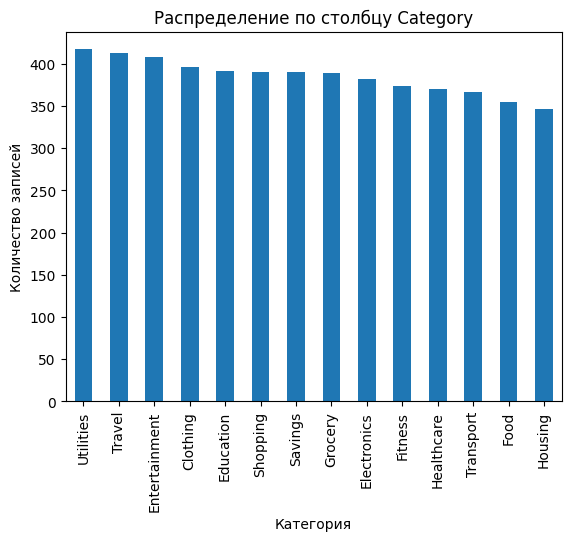

Category
Utilities        417
Travel           413
Entertainment    408
Clothing         396
Education        391
Shopping         390
Savings          390
Grocery          389
Electronics      382
Fitness          374
Healthcare       370
Transport        367
Food             355
Housing          347
Name: count, dtype: int64

In [8]:
df['Category'].value_counts().plot(kind='bar')
plt.title('Распределение по столбцу Category')
plt.xlabel('Категория')
plt.ylabel('Количество записей')
plt.show()
df['Category'].value_counts()

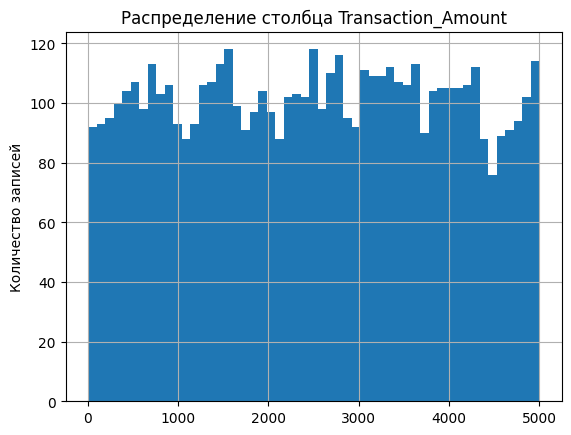

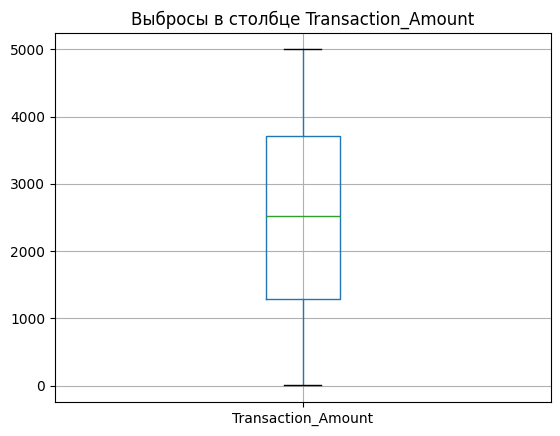

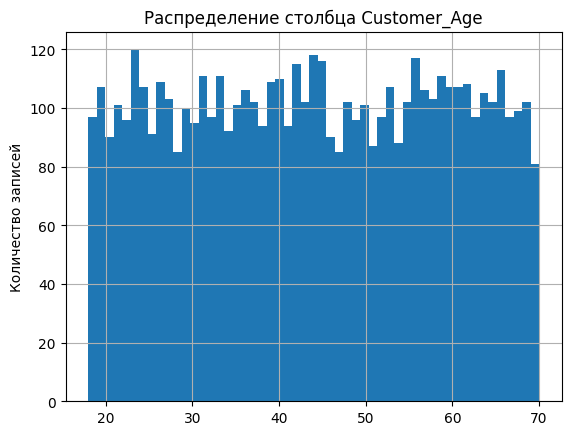

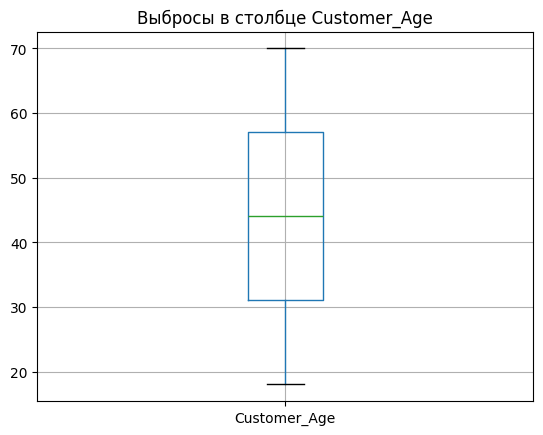

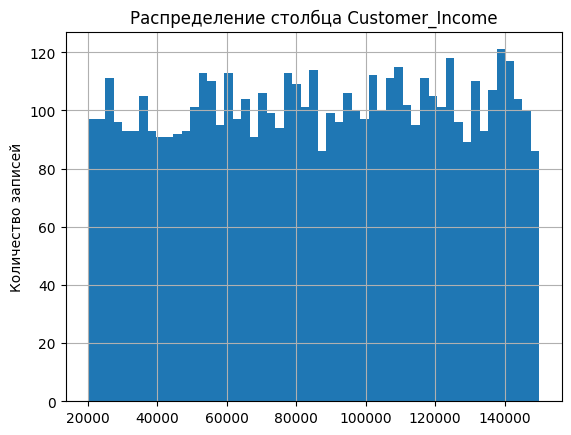

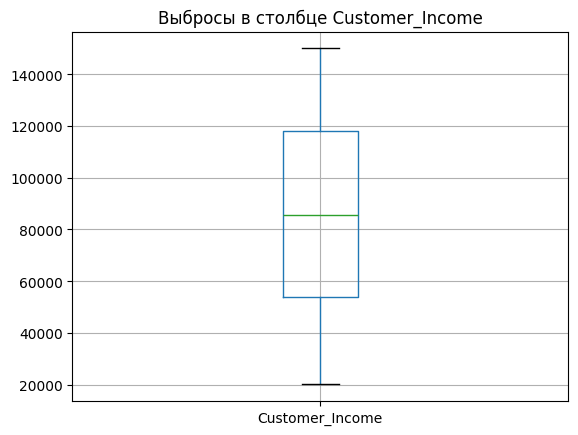

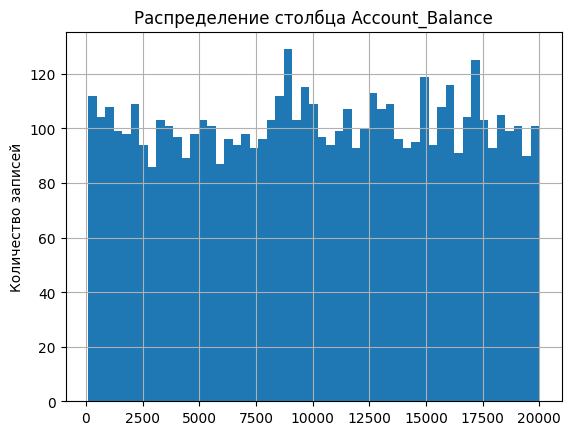

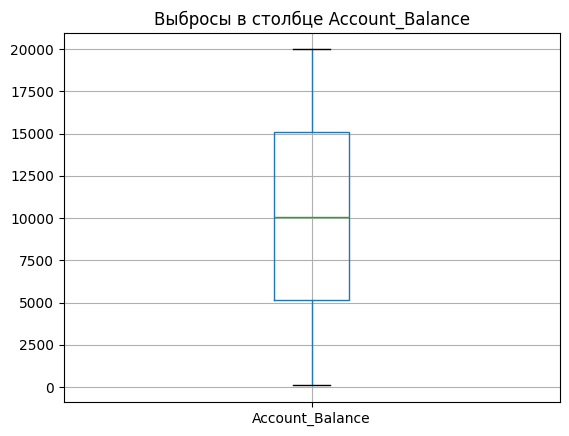

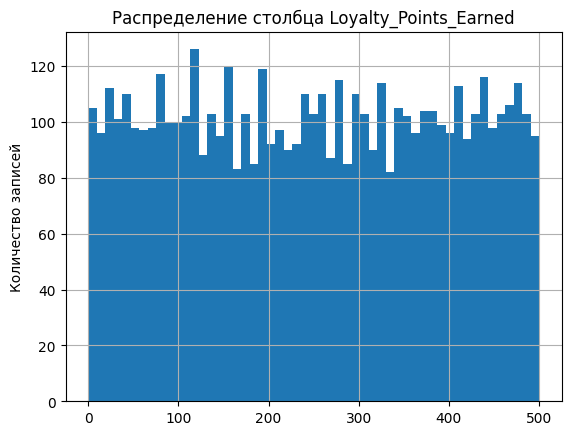

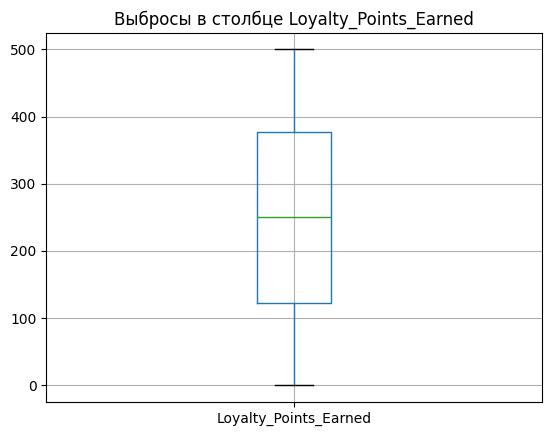

In [9]:
for column in df.select_dtypes(include=np.number):
    df[column].hist(bins=53)
    plt.title(f'Распределение столбца {column}')
    plt.ylabel('Количество записей')
    plt.show()

    df.boxplot(column)
    plt.title(f'Выбросы в столбце {column}')
    plt.show()

In [10]:
df.select_dtypes(include=np.number).corr()

,Transaction_Amount,Customer_Age,Customer_Income,Account_Balance,Loyalty_Points_Earned
Transaction_Amount,1.000000,0.002677,0.003116,-0.001018,0.013251
Customer_Age,0.002677,1.000000,0.005571,0.014531,0.014407
Customer_Income,0.003116,0.005571,1.000000,0.005566,-0.003832
Account_Balance,-0.001018,0.014531,0.005566,1.000000,0.016672
Loyalty_Points_Earned,0.013251,0.014407,-0.003832,0.016672,1.000000


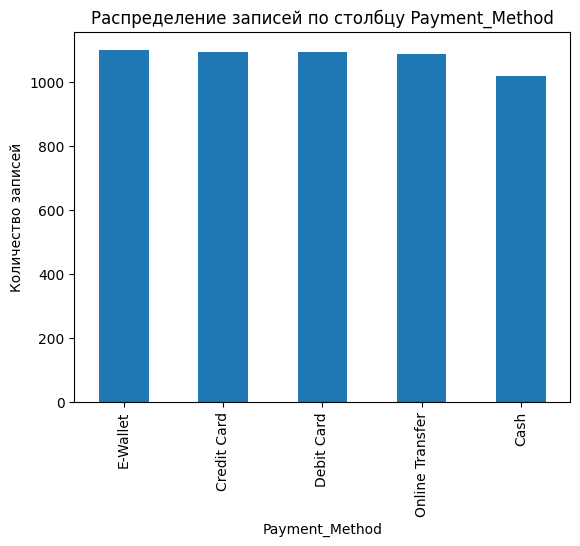

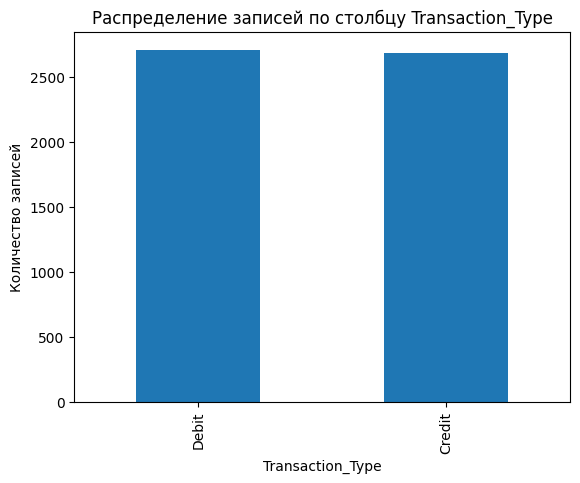

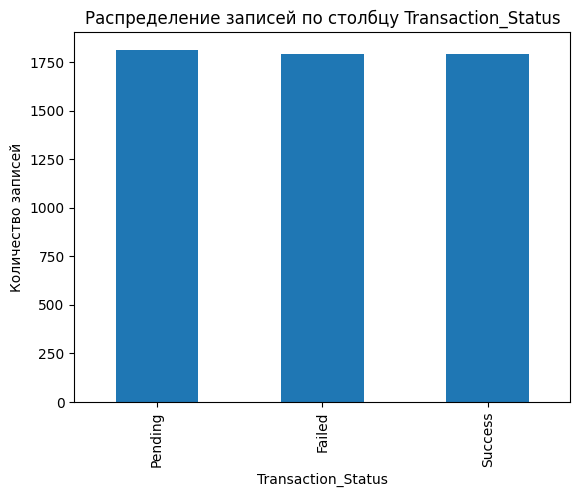

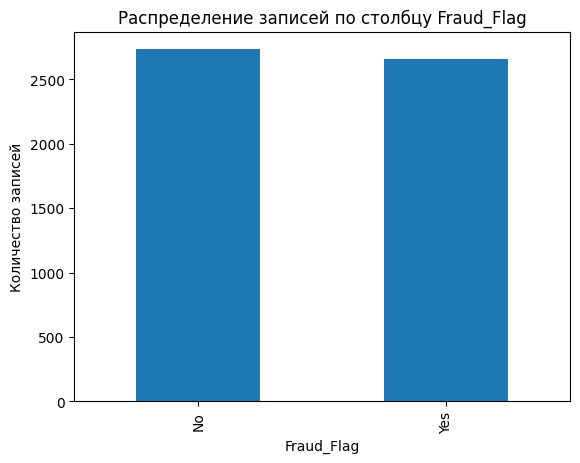

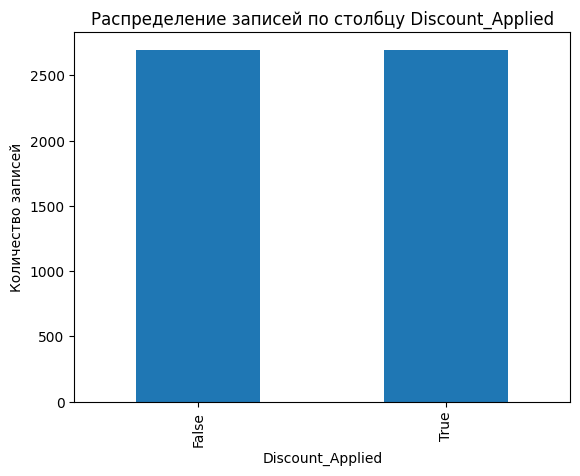

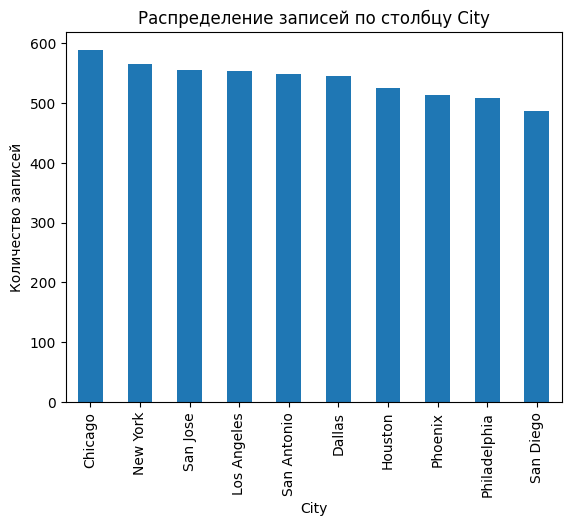

In [11]:
for column in ['Payment_Method', 'Transaction_Type', 'Transaction_Status', 'Fraud_Flag', 'Discount_Applied', 'City']:
    df[column].value_counts().plot(kind='bar')
    plt.title(f'Распределение записей по столбцу {column}')
    plt.ylabel('Количество записей')
    plt.show()

In [12]:
df['City'].value_counts()

City
Chicago         589
New York        565
San Jose        555
Los Angeles     554
San Antonio     548
Dallas          545
Houston         525
Phoenix         513
Philadelphia    508
San Diego       487
Name: count, dtype: int64

**Промежуточный вывод по исследовательскому анализу данных:** 
- Записи по целевому признаку `Category` распределены почти равномерно, в диапазоне от 347 до 417. Поэтому редких классов не выявлено. Данный момент меня наталкивает на мысль, о том что балансировать классы не нужно будет, так как дисбаланса нет.
- Также были проверены наиболее важные столбцы с типом данных `str` и во всех из них данные распределены равномерно.
- Числовые признаки также распределены приблизительно равномерно, гипотеза с обзора данных подтвердилась. Коэффициент корреляции Пирсона показывает, что между числовыми признаками нет линейной взаимосвязи. Выбросов нет ни в одном столбце.

### Подготовка данных для машинного обучения и сборка пайплайна

In [13]:
y = df['Category']
X = df.drop(['Category', 'Country'], axis=1)
X.head()

,Transaction_ID,Account_Number,Transaction_Date,Transaction_Amount,Merchant_Name,Transaction_Type,City,Payment_Method,Customer_Age,Customer_Gender,Customer_Occupation,Customer_Income,Account_Balance,Transaction_Status,Fraud_Flag,Discount_Applied,Loyalty_Points_Earned,Transaction_Description
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,IUPM04409079772781,2023-11-05 15:54:38,3198.94,Houston Group,Debit,Phoenix,Online Transfer,55,Others,Quality manager,80466.03,350.28,Failed,No,True,304,Recently company detail form range a.
1,23b8c1e9-3924-46de-beb1-3b9046685257,BLAT22216107051843,2024-04-21 22:21:55,129.93,Anderson-Phillips,Credit,Philadelphia,Debit Card,26,Others,Civil Service fast streamer,145574.25,9797.81,Pending,Yes,False,383,Anything son baby power heart will not up.
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,UTXA55295806601382,2023-07-17 13:25:56,1378.77,Jensen Group,Credit,New York,Debit Card,29,Others,"Pilot, airline",33447.18,12399.85,Failed,Yes,False,497,Form world around green bar environment pattern.
3,972a8469-1641-4f82-8b9d-2434e465e150,XICF70493862044851,2023-06-27 16:09:52,1119.94,"Nelson, Gomez and Rodriguez",Credit,Dallas,Online Transfer,60,Male,"Radiographer, therapeutic",108801.45,16057.64,Failed,Yes,True,495,Order evening source these opportunity trade i...
4,17fc695a-07a0-4a6e-8822-e8f36c031199,KOSW19711121259020,2024-03-26 23:45:31,3683.67,Caldwell Group,Credit,San Jose,E-Wallet,29,Others,Diplomatic Services operational officer,100985.12,14940.54,Failed,Yes,True,292,Exactly politics door suggest.


In [14]:
X['dayofweek'] = X['Transaction_Date'].dt.dayofweek
X['month'] = X['Transaction_Date'].dt.month
X['is_weekend'] = (X['Transaction_Date'].dt.dayofweek >= 5).astype(int)
X['Discount_Applied'] = X['Discount_Applied'].astype(int)
X['Fraud_Flag'] = X['Fraud_Flag'].map({'Yes': 1, 'No': 0})
X.head()

,Transaction_ID,Account_Number,Transaction_Date,Transaction_Amount,Merchant_Name,Transaction_Type,City,Payment_Method,Customer_Age,Customer_Gender,...,Customer_Income,Account_Balance,Transaction_Status,Fraud_Flag,Discount_Applied,Loyalty_Points_Earned,Transaction_Description,dayofweek,month,is_weekend
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,IUPM04409079772781,2023-11-05 15:54:38,3198.94,Houston Group,Debit,Phoenix,Online Transfer,55,Others,...,80466.03,350.28,Failed,0,1,304,Recently company detail form range a.,6,11,1
1,23b8c1e9-3924-46de-beb1-3b9046685257,BLAT22216107051843,2024-04-21 22:21:55,129.93,Anderson-Phillips,Credit,Philadelphia,Debit Card,26,Others,...,145574.25,9797.81,Pending,1,0,383,Anything son baby power heart will not up.,6,4,1
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,UTXA55295806601382,2023-07-17 13:25:56,1378.77,Jensen Group,Credit,New York,Debit Card,29,Others,...,33447.18,12399.85,Failed,1,0,497,Form world around green bar environment pattern.,0,7,0
3,972a8469-1641-4f82-8b9d-2434e465e150,XICF70493862044851,2023-06-27 16:09:52,1119.94,"Nelson, Gomez and Rodriguez",Credit,Dallas,Online Transfer,60,Male,...,108801.45,16057.64,Failed,1,1,495,Order evening source these opportunity trade i...,1,6,0
4,17fc695a-07a0-4a6e-8822-e8f36c031199,KOSW19711121259020,2024-03-26 23:45:31,3683.67,Caldwell Group,Credit,San Jose,E-Wallet,29,Others,...,100985.12,14940.54,Failed,1,1,292,Exactly politics door suggest.,1,3,0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [16]:
preprocessor_test = ColumnTransformer([
    ('text', TfidfVectorizer(), 'Transaction_Description')
])

In [17]:
pipe_lr_test = Pipeline([
    ('prep', preprocessor_test),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

In [18]:
pipe_lr_test.fit(X_train, y_train)
prediction_test = pipe_lr_test.predict(X_test)
print(f1_score(y_test, prediction_test, average='macro'))

0.062249657093948745


In [19]:
preprocessor_test = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['Merchant_Name'])
])

In [20]:
pipe_lr_test = Pipeline([
    ('prep', preprocessor_test),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

In [21]:
pipe_lr_test.fit(X_train, y_train)
prediction_test = pipe_lr_test.predict(X_test)
print(f1_score(y_test, prediction_test, average='macro'))

0.024496625042315166


In [22]:
preprocessor_test = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['Customer_Occupation'])
])

In [23]:
pipe_lr_test = Pipeline([
    ('prep', preprocessor_test),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

In [24]:
pipe_lr_test.fit(X_train, y_train)
prediction_test = pipe_lr_test.predict(X_test)
print(f1_score(y_test, prediction_test, average='macro'))

0.0775410754697076


**Пояснение:** Убрал из датасета столбец `Country`, так как там всего одно значение. Также проверил столбцы `Transaction_Description`, `Merchant_Name` и `Customer_Occupation`. `Transaction_Description` убрал из-за небольшой разницы между f1 на нём (0.0622) и f1 случайного угадывания (1/14 = 0.0714), также при визуальном анализе стало понятно, что текст не несёт никакой информации и скорее всего сгенерирован синтетически. `Merchant_Name` и `Customer_Occupation` также не использую из-за малого f1 (0.0244 и 0.0775 соответственно), такие показатели вероятно из-за большого количества уникальных значений в данных столбцах (4880 и 639 соответственно).

### Обучение моделей

In [25]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['Transaction_Amount', 'Customer_Age', 'Customer_Income', 'Account_Balance', 'Loyalty_Points_Earned']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['Transaction_Type', 'dayofweek', 'month', 'City', 'Payment_Method', 'Customer_Gender', 'Transaction_Status']),
    ('bin', 'passthrough', ['Fraud_Flag', 'Discount_Applied', 'is_weekend'])
])

#### LogisticRegression

In [26]:
pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

In [27]:
%%time
param_grid_lr = {
    'model__C': [0.1, 1, 10],
    'model__class_weight': [None, 'balanced'],
    'model__solver': ['saga'],
    'model__l1_ratio': [0, 0.5, 1]
}
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring='f1_macro', n_jobs=-1)
grid_lr.fit(X_train, y_train)
print(grid_lr.best_score_, grid_lr.best_params_)

0.07394099028766576 {'model__C': 1, 'model__class_weight': 'balanced', 'model__l1_ratio': 1, 'model__solver': 'saga'}
CPU times: total: 1.42 s
Wall time: 26.4 s


#### RandomForestClassifier

In [28]:
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [29]:
%%time
param_rand_rf = {
    'model__n_estimators': [i for i in range(20, 261, 40)],
    'model__max_depth': [i for i in range(2, 23, 4)],
    'model__class_weight': [None, 'balanced'],
    'model__max_features': ['sqrt', 'log2']
}

rand_rf = RandomizedSearchCV(pipe_rf, param_rand_rf, random_state=42, n_iter=40, cv=5, scoring='f1_macro', n_jobs=-1)
rand_rf.fit(X_train, y_train)
print(rand_rf.best_score_, rand_rf.best_params_)

0.07811384992554592 {'model__n_estimators': 20, 'model__max_features': 'sqrt', 'model__max_depth': 18, 'model__class_weight': None}
CPU times: total: 2.11 s
Wall time: 16.7 s


In [30]:
%%time
param_grid_rf = {
    'model__n_estimators': [i for i in range(5, 36, 5)],
    'model__max_depth': [i for i in range(14, 29, 2)],
    'model__class_weight': [None, 'balanced'],
    'model__max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(grid_rf.best_score_, grid_rf.best_params_)

0.08129147795378514 {'model__class_weight': None, 'model__max_depth': 18, 'model__max_features': 'sqrt', 'model__n_estimators': 30}
CPU times: total: 5.94 s
Wall time: 25.5 s


#### LightGBM

In [31]:
pipe_lgbm = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMClassifier(random_state=42))
])

In [32]:
%%time
param_grid_lgbm = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves': [15, 31, 60],
    'model__max_depth': [3, 5, 7, -1]
}

grid_lgbm = GridSearchCV(pipe_lgbm, param_grid_lgbm, cv=5, scoring='f1_macro', n_jobs=-1)
grid_lgbm.fit(X_train, y_train)
print(grid_lgbm.best_score_, grid_lgbm.best_params_)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1163
[LightGBM] [Info] Number of data points in the train set: 4041, number of used features: 50
[LightGBM] [Info] Start training from score -2.610515
[LightGBM] [Info] Start training from score -2.624075
[LightGBM] [Info] Start training from score -2.648256
[LightGBM] [Info] Start training from score -2.580662
[LightGBM] [Info] Start training from score -2.665893
[LightGBM] [Info] Start training from score -2.720751
[LightGBM] [Info] Start training from score -2.627494
[LightGBM] [Info] Start training from score -2.676626
[LightGBM] [Info] Start training from score -2.743566
[LightGBM] [Info] Start training from score -2.627494
[LightGBM] [Info] Start training from score -2.627494
[LightGBM] [Info] Start training from score -2.687476


In [33]:
columns = ['model', 'macro_f1']
data = [['Logistic Regression', grid_lr.best_score_], ['RandomForestClassifier', grid_rf.best_score_], ['LGBMClassifier', grid_lgbm.best_score_]]
pivot_table_models = pd.DataFrame(data=data, columns=columns)
pivot_table_models

,model,macro_f1
0,Logistic Regression,0.073941
1,RandomForestClassifier,0.081291
2,LGBMClassifier,0.078831


**Вывод:** Все модели получили приблизительно равный около случайный Macro f1, предполагаю, что и на тестовой выборке будут подобные результаты или хуже. Для проверки своей гипотезы я запущу RandomForestClassifier на тестовой выборке.

### Проверка RandomForestClassifier на тестовой выборке

In [34]:
y_pred = grid_rf.best_estimator_.predict(X_test)
print('Macro F1 случайного леса на тестовой выборке:', f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

Macro F1 случайного леса на тестовой выборке: 0.07486674565220748
               precision    recall  f1-score   support

     Clothing       0.06      0.06      0.06        99
    Education       0.08      0.08      0.08        98
  Electronics       0.07      0.07      0.07        96
Entertainment       0.06      0.07      0.07       102
      Fitness       0.04      0.04      0.04        93
         Food       0.03      0.02      0.03        89
      Grocery       0.06      0.06      0.06        97
   Healthcare       0.10      0.10      0.10        92
      Housing       0.12      0.09      0.11        87
      Savings       0.09      0.10      0.10        98
     Shopping       0.10      0.09      0.09        98
    Transport       0.10      0.09      0.09        92
       Travel       0.09      0.10      0.09       103
    Utilities       0.06      0.07      0.06       104

     accuracy                           0.07      1348
    macro avg       0.08      0.07      0.07      13

In [35]:
df.groupby('Category')[
    ['Transaction_Amount', 'Customer_Age', 'Customer_Income', 'Account_Balance']
].mean()

,Transaction_Amount,Customer_Age,Customer_Income,Account_Balance
Category,,,,
Clothing,2531.051667,43.729798,86903.389571,9758.594621
Education,2497.797161,44.335038,85229.735013,10480.186598
Electronics,2535.373796,43.167539,85545.117880,10027.335314
Entertainment,2497.184020,44.475490,87490.277941,10587.434534
Fitness,2484.721150,43.906417,85378.685214,10565.754545
Food,2734.927831,43.692958,82591.372282,10268.792817
Grocery,2491.528535,43.642674,83613.334396,10194.104807
Healthcare,2408.916378,44.678378,89489.788054,9953.443054
Housing,2459.406254,43.870317,84899.126715,10408.575476


**Итоговый вывод:** Результат RandomForest на тестовой выборке остался близким к случайному (0.0748), что подтверждает мою гипотезу сделанную в предыдущем разделе. Classification_report тоже не показал высоких показателей для отедльных классов, благодаря чему можно сказать, что датасет сформирован синтетически и в нём нет никаких признаков, благодаря которым различаются категории транзакций. Также я посчитал средние значения для всех столбцов с числовым типом данных, сгруппированных по целевому признаку, и средние почти никак не различаются, что подтверждает синтетическое происхождение датасета.